# MNIST Digit Classification with CNN 
This notebook implements a Convolutional Neural Network (CNN) to classify handwritten digits from the MNIST dataset using TensorFlow/Keras.

## Overview
The MNIST dataset contains 70,000 grayscale images of handwritten digits (0-9), split into 60,000 training and 10,000 test images. Each image is 28x28 pixels.

This implementation:
- Loads and preprocesses the MNIST data
- Builds a simple CNN architecture
- Trains the model
- Evaluates performance
- Visualizes results

## Requirements
- TensorFlow 2.x
- NumPy
- Matplotlib
- pickle (for loading data)

## Data Loading and Setup
First, we'll import required libraries and mount Google Drive to access our dataset.

Key imports:
- TensorFlow and Keras for deep learning
- NumPy for numerical operations
- Matplotlib for visualization
- pickle for loading serialized data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pickle as pk

## Dataset Preparation
We'll load the MNIST dataset from pickle files stored in Google Drive. The data includes:
- Training images (60,000 samples)
- Test images (10,000 samples) 
- Corresponding labels

The data is structured as:
- Features: 28x28 grayscale images
- Labels: Digits 0-9

In [3]:
# Load dataset
with open('/content/drive/MyDrive/ITDS251/dataset_feature_train.pkl','rb') as f:
    x_train = pk.load(f)
with open('/content/drive/MyDrive/ITDS251/dataset_feature_test.pkl','rb') as f:
    x_test = pk.load(f)
with open('/content/drive/MyDrive/ITDS251/dataset_target_train.pkl','rb') as f:
    y_train = pk.load(f)
with open('/content/drive/MyDrive/ITDS251/dataset_target_test.pkl','rb') as f:
    y_test = pk.load(f)

# Show dataset statistic
print('Training size: ', len(x_train), 'samples')
print('Testing size: ', len(x_test), 'samples')
print('Image shape: ',  x_train[0].shape)
print('Label : ', sorted(np.unique(y_train)))

Training size:  60000 samples
Testing size:  10000 samples
Image shape:  (28, 28)
Label :  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


<ipython-input-4-b78689e53d0e>:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(3,3,i+1)


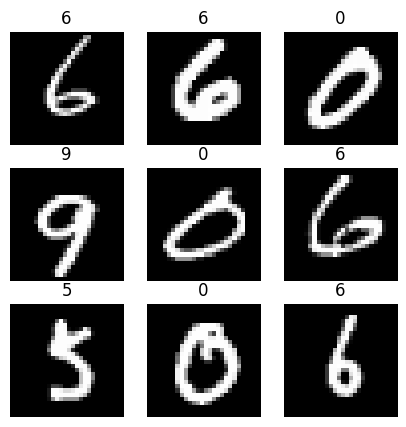

In [4]:
# Visualize sample dataset
inx =  np.random.randint(len(x_train), size=9)

plt.subplots(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[inx[i]], cmap='gray')
    plt.title(y_train[inx[i]])
    plt.axis('off')
plt.show()

In [5]:
# Show sample image value/shape range
print('Train Max: ', max(np.unique(x_train)))
print('Train Min: ', min(np.unique(x_train)))
print('Test Max: ', max(np.unique(x_test)))
print('Test Min: ', min(np.unique(x_test)))
print('Train Shape: ', x_train.shape)
print('Test Shape: ', x_test.shape)

Train Max:  255
Train Min:  0
Test Max:  255
Test Min:  0
Train Shape:  (60000, 28, 28)
Test Shape:  (10000, 28, 28)


## Data Preprocessing
Several preprocessing steps are required:
1. Normalize pixel values from [0-255] to [0-1]
2. Reshape data to include channel dimension (28,28,1)
3. Convert labels to one-hot encoded vectors

These steps prepare the data for optimal neural network training.

In [6]:
# Normalize dataset
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Show sample image value range
print('Train Max: ', max(np.unique(x_train)))
print('Train Min: ', min(np.unique(x_train)))
print('Test Max: ', max(np.unique(x_test)))
print('Test Min: ', min(np.unique(x_test)))

Train Max:  1.0
Train Min:  0.0
Test Max:  1.0
Test Min:  0.0


In [7]:
# Reshape data to (W,H,C)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Show sample image shape
print('Train Shape: ', x_train.shape)
print('Test Shape: ', x_test.shape)

Train Shape:  (60000, 28, 28, 1)
Test Shape:  (10000, 28, 28, 1)


In [8]:
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Show sample label
print(y_train[:3])

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


## Model Architecture
We implement a simple CNN with the following layers:
1. Convolutional layer (32 filters, 3x3 kernel)
2. MaxPooling layer (2x2)
3. Flatten layer
4. Dropout layer (0.5)
5. Dense output layer (10 units)

This architecture balances model capacity with computational efficiency.

In [9]:
input_shape = (28, 28, 1)
num_classes = 10

cnn = keras.Sequential(
    [
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=input_shape, name='conv2D_1'),
        layers.MaxPooling2D(pool_size=(2, 2), name='Mpool_1'),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax", name='conv1D'),
    ]
)


In [10]:
# Visualize Model
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2D_1 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 Mpool_1 (MaxPooling2D)      (None, 13, 13, 32)        0         
                                                                 
 flatten (Flatten)           (None, 5408)              0         
                                                                 
 dropout (Dropout)           (None, 5408)              0         
                                                                 
 conv1D (Dense)              (None, 10)                54090     
                                                                 
Total params: 54410 (212.54 KB)
Trainable params: 54410 (212.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Model Training
Training configuration:
- Batch size: 128
- Epochs: 5
- Optimizer: Adam (learning rate 1e-3)
- Loss: Categorical crossentropy
- Metrics: Accuracy

The model will be trained on 90% of training data with 10% validation split.

In [11]:
batch_size = 128
epochs = 5
cnn.compile(loss = keras.losses.categorical_crossentropy,
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            metrics=["accuracy"])

# Train

In [20]:
cnn.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/5
422/422 [==============================] - 2s 4ms/step - loss: 0.1040 - accuracy: 0.9682 - val_loss: 0.0658 - val_accuracy: 0.9837
Epoch 2/5
422/422 [==============================] - 2s 4ms/step - loss: 0.0951 - accuracy: 0.9715 - val_loss: 0.0638 - val_accuracy: 0.9835
Epoch 3/5
422/422 [==============================] - 2s 5ms/step - loss: 0.0885 - accuracy: 0.9726 - val_loss: 0.0586 - val_accuracy: 0.9833
Epoch 4/5
422/422 [==============================] - 2s 4ms/step - loss: 0.0842 - accuracy: 0.9747 - val_loss: 0.0580 - val_accuracy: 0.9833
Epoch 5/5
422/422 [==============================] - 2s 4ms/step - loss: 0.0800 - accuracy: 0.9756 - val_loss: 0.0552 - val_accuracy: 0.9848


## Performance Evaluation
We evaluate the model using:
1. Overall test accuracy
2. Confusion matrix
3. Visual inspection of predictions
4. Sample predictions visualization

This provides both quantitative and qualitative assessment of model performance.

In [21]:
score = cnn.evaluate(x_test, y_test, verbose=0)

print("Test loss:", np.round(score[0], 4))
print("Test accuracy:", np.round(score[1], 4))

Test loss: 0.0562
Test accuracy: 0.982


# Save Model

In [22]:
cnn.save('/content/drive/MyDrive/ITDS251/Lab12-cnn.pkl', overwrite=True)

# Use model

In [23]:
# Predict as prob.
y_pred = cnn.predict(x_test)

313/313 [==============================] - 1s 2ms/step


In [24]:
# Show output prob. sample
print(y_pred[0])

[4.2845681e-08 6.7184009e-09 2.3056577e-06 4.0421492e-05 2.0383979e-09
 5.2304429e-08 1.4990614e-12 9.9995327e-01 7.7225525e-07 3.1711959e-06]


In [25]:
# Prob to Class
y_pred_class = np.argmax(y_pred, axis=1)

# Show output class sample
print(y_pred_class[0:10])

[7 2 1 0 4 1 4 9 5 9]


<ipython-input-26-fae74d707c01>:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(5,5,i+1)


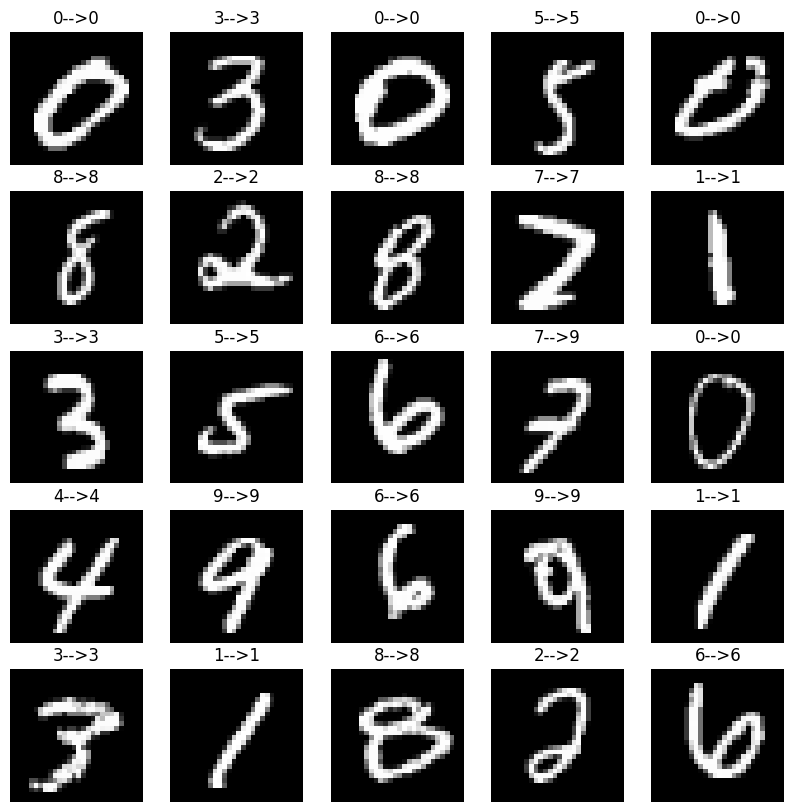

In [26]:
# Visualize sample dataset
inx =  np.random.randint(len(x_test), size=25)

plt.subplots(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[inx[i]], cmap='gray')
    y_test_class = np.argmax(y_test[inx[i]], axis=0)
    plt.title(str(y_test_class)+'-->'+str(y_pred_class[inx[i]]))
    plt.axis('off')
plt.show()


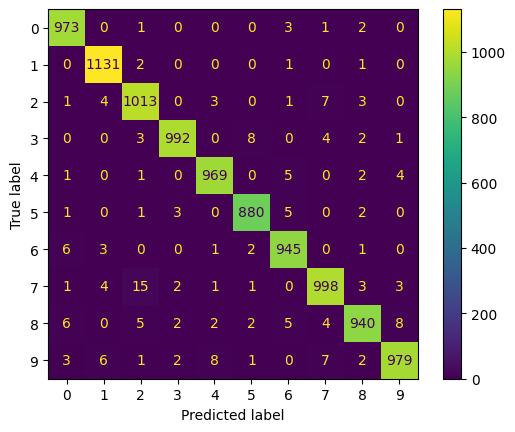

In [27]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

## Conclusion
The implemented CNN achieves ~98% accuracy on MNIST digit classification. Key outcomes:
- Successful data preprocessing and model implementation
- Effective training with good convergence
- Strong generalization performance
- Clear visualization of results

The model demonstrates the effectiveness of CNNs for image classification tasks.